# 02 Economic Regime: 多変量 Gaussian HMM

7 系列を観測として 3 状態 HMM でレジームを抽出する。


In [ ]:
from __future__ import annotations

import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import _helpers as h
import japanize_matplotlib  # 日本語フォント設定（seaborn の後にロード）
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from hmmlearn.hmm import GaussianHMM

sns.set_theme(style="whitegrid")
japanize_matplotlib.japanize()  # seaborn が font.family を上書きするため、明示的に再設定
np.random.seed(42)

## 特徴量読み込み


In [ ]:
features = pd.read_parquet(h.FEATURES_WEEKLY_PARQUET)
df_raw = pd.read_parquet(h.FRED_WEEKLY_RAW_PARQUET)
print(f"Features: {features.shape}")
features.head()

Features: (1111, 7)


,INDPRO,ICSA,T10YIE,CPIAUCSL,STLFSI4,BAA10Y,T10Y2Y
2004-12-24,0.678741,-0.173538,1.282396,0.405329,-0.678421,-0.645416,0.256515
2004-12-31,0.643846,-0.176615,1.157579,0.167704,-0.675549,-0.709112,0.203586
2005-01-07,0.726315,-0.167352,0.982834,0.138961,-0.587269,-0.747330,0.129487
2005-01-14,0.726315,-0.142488,1.032761,0.138961,-0.564966,-0.798287,0.023630
2005-01-21,0.726315,-0.141577,0.932907,0.138961,-0.575526,-0.798287,0.034215


## HMM 学習

3 状態 Gaussian HMM、full 共分散、200 iter。


In [ ]:
X = features.values
model = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=200,
    random_state=42,
)
model.fit(X)
print(f"Converged: {model.monitor_.converged}")
print(f"Log-likelihood: {model.score(X):.2f}")

Converged: True
Log-likelihood: -4351.77


## 状態予測とラベル割当


In [ ]:
states = pd.Series(model.predict(X), index=features.index, name="state")
proba = pd.DataFrame(
    model.predict_proba(X),
    index=features.index,
    columns=[f"P(state={i})" for i in range(3)],
)

# INDPRO YoYで状態ラベル割当 (生YoYを再計算)
indpro_yoy = (df_raw["INDPRO"] / df_raw["INDPRO"].shift(52) - 1.0) * 100.0
indpro_yoy = indpro_yoy.dropna()

state_labels = h.label_hmm_states(states, indpro_yoy)
print("State labels:", state_labels)
states_labeled = states.map(state_labels)
states_labeled.value_counts()

State labels: {2: '拡大', 0: '減速', 1: '後退・ストレス'}


state
拡大         936
減速         104
後退・ストレス     71
Name: count, dtype: int64

## 遷移確率行列


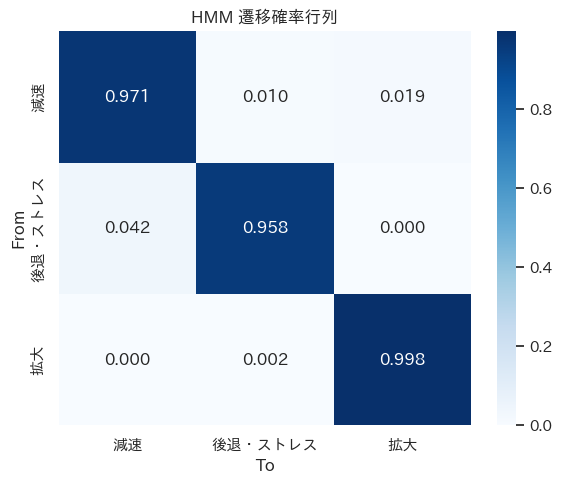

In [ ]:
trans_df = pd.DataFrame(
    model.transmat_,
    index=[state_labels[i] for i in range(3)],
    columns=[state_labels[i] for i in range(3)],
)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(trans_df, annot=True, fmt=".3f", cmap="Blues", ax=ax)
ax.set_title("HMM 遷移確率行列")
ax.set_xlabel("To")
ax.set_ylabel("From")
plt.tight_layout()
plt.show()

## レジーム背景塗りつぶし + INDPRO YoY 重ね描き


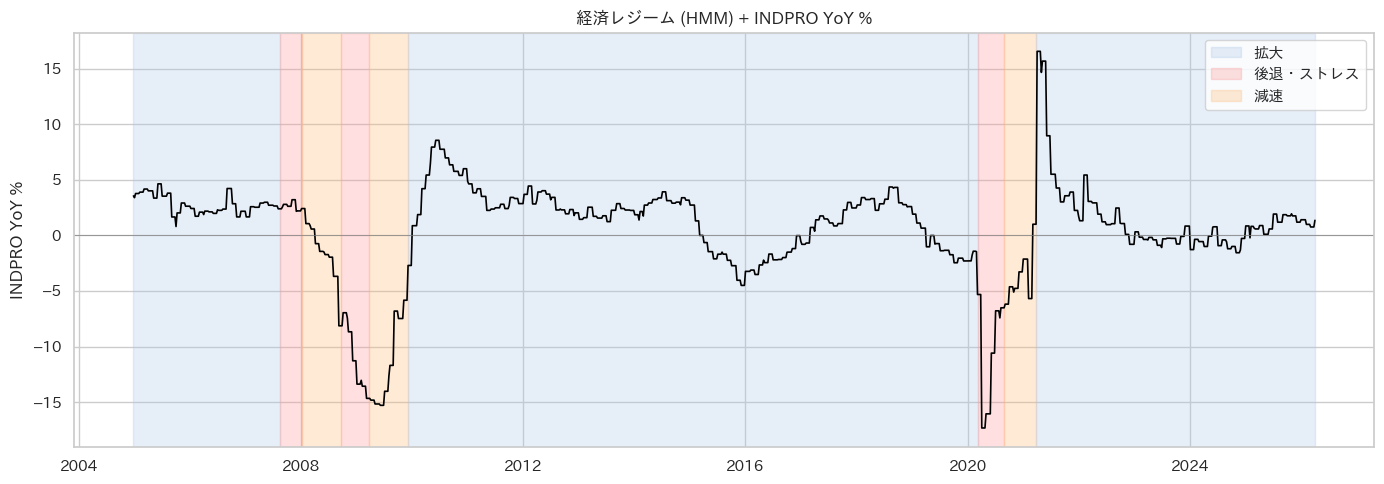

In [ ]:
palette = {
    [k for k, v in state_labels.items() if v == "拡大"][0]: "#aec7e8",
    [k for k, v in state_labels.items() if v == "減速"][0]: "#ffbb78",
    [k for k, v in state_labels.items() if v == "後退・ストレス"][0]: "#ff9896",
}

fig, ax = plt.subplots(figsize=(14, 5))
# INDPRO YoY を共通インデックスに揃え
indpro_aligned = indpro_yoy.reindex(states.index).ffill()
h.plot_regime_overlay(
    ax=ax,
    series=indpro_aligned,
    regimes=states,
    palette=palette,
    labels=state_labels,
)
ax.set_title("経済レジーム (HMM) + INDPRO YoY %")
ax.set_ylabel("INDPRO YoY %")
ax.legend(loc="upper right")
ax.axhline(0, color="grey", linewidth=0.5)
plt.tight_layout()
plt.show()

## レジーム別の特徴量平均


In [ ]:
features_with_regime = features.copy()
features_with_regime["regime"] = states_labeled.values
regime_mean = features_with_regime.groupby("regime").mean().round(2)
regime_mean

,INDPRO,ICSA,T10YIE,CPIAUCSL,STLFSI4,BAA10Y,T10Y2Y
regime,,,,,,,
後退・ストレス,-1.66,1.79,-1.76,-0.48,2.44,1.60,0.11
拡大,0.28,-0.19,0.16,0.09,-0.27,-0.22,-0.09
減速,-1.36,0.46,-0.23,-0.44,0.78,0.92,0.71


## 状態事前確率の積み上げチャート


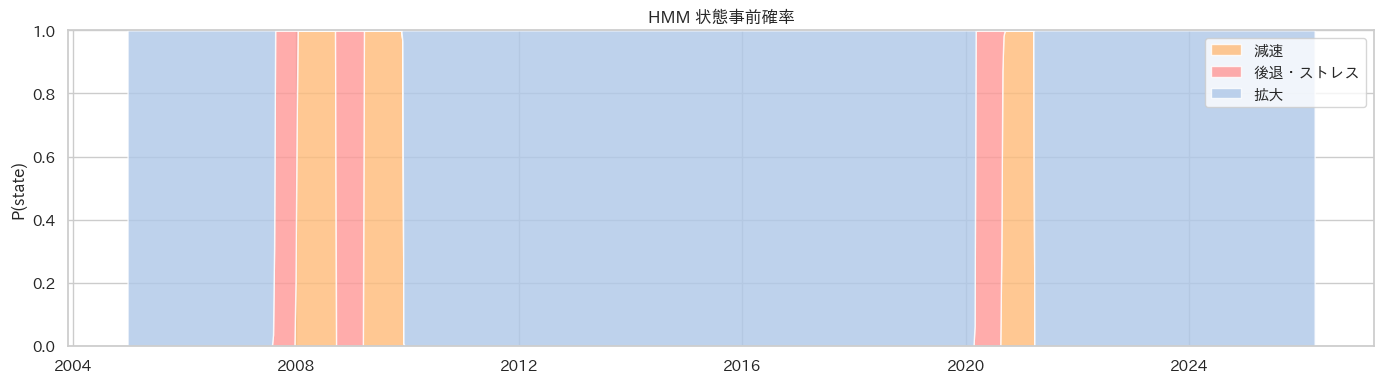

In [ ]:
proba_renamed = proba.copy()
proba_renamed.columns = [state_labels[i] for i in range(3)]
fig, ax = plt.subplots(figsize=(14, 4))
ax.stackplot(
    proba_renamed.index,
    proba_renamed.T.values,
    labels=proba_renamed.columns,
    colors=[palette[i] for i in range(3)],
    alpha=0.8,
)
ax.set_title("HMM 状態事前確率")
ax.set_ylabel("P(state)")
ax.set_ylim(0, 1)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 結果の保存


In [ ]:
output = pd.DataFrame(
    {
        "state_id": states,
        "regime": states_labeled,
    }
)
output = output.join(proba_renamed)
output.to_parquet(h.DATA_DIR / "economic_regime_hmm.parquet")
print(f"Saved: {h.DATA_DIR / 'economic_regime_hmm.parquet'}")

Saved: /Users/yukihata/Desktop/quants/notebook/REGIME_SWITCHING/data/economic_regime_hmm.parquet
